In [1]:
print("Hello Vinay!")

Hello Vinay!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
df = pd.read_csv("retail_sales.csv") 

In [6]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.shape

(1000, 9)

In [8]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [9]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [15]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [16]:
numeric_cols = df.select_dtypes(include=np.number)

print("MEAN:")
print(numeric_cols.mean())

print("\nMEDIAN:")
print(numeric_cols.median())

print("\nMODE:")
print(numeric_cols.mode().iloc[0])

print("\nSTANDARD DEVIATION:")
print(numeric_cols.std())

MEAN:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

MEDIAN:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

MODE:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

STANDARD DEVIATION:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [17]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

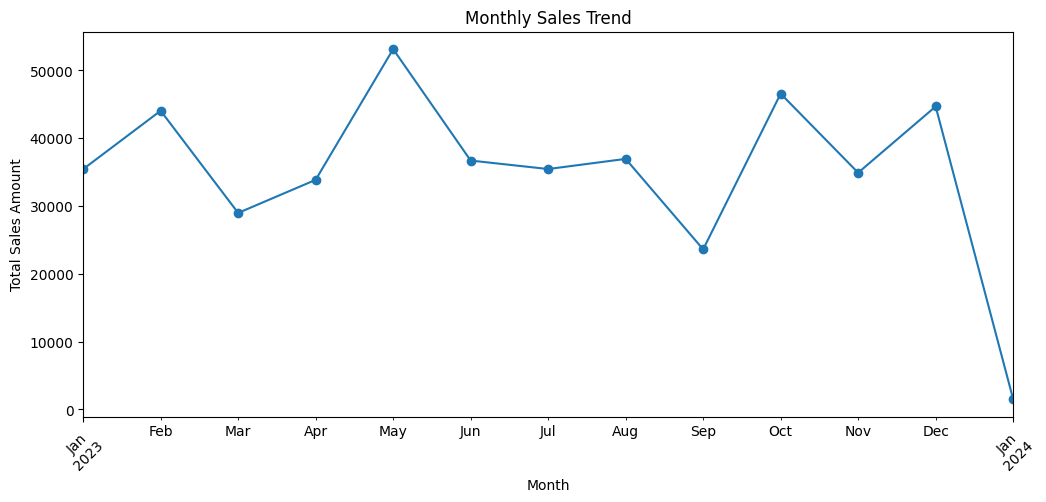

In [18]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)

plt.show()

### Observation:

Monthly sales fluctuate throughout the year. Sales reached their highest level in May 2023 at approximately 53k, while September 2023 recorded the lowest sales among the complete months at approximately 24k. Sales increased again in October 2023, reaching approximately 47k. The January 2024 value is not considered for full-month comparison because the dataset ends on January 1, 2024.

In [19]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

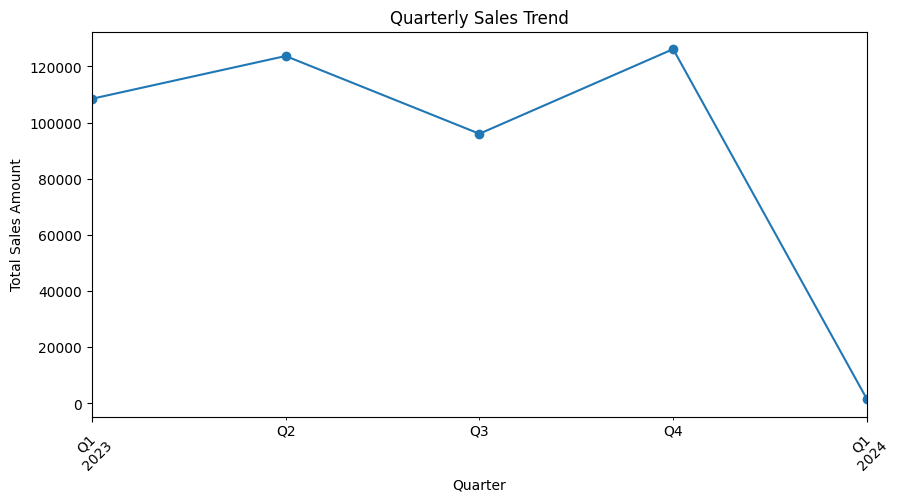

In [20]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)

plt.show()

### Observation

Quarterly sales show noticeable variation throughout 2023. Q2 2023 recorded approximately 124K in sales, while Q3 2023 decreased to approximately 96K. Sales increased again in Q4 2023 to approximately 126K, which was the highest complete quarter in the dataset. The Q1 2024 value is not directly comparable because the dataset only contains data up to January 1, 2024.

In [21]:
gender_count = df['Gender'].value_counts()

gender_count

Gender
Female    510
Male      490
Name: count, dtype: int64

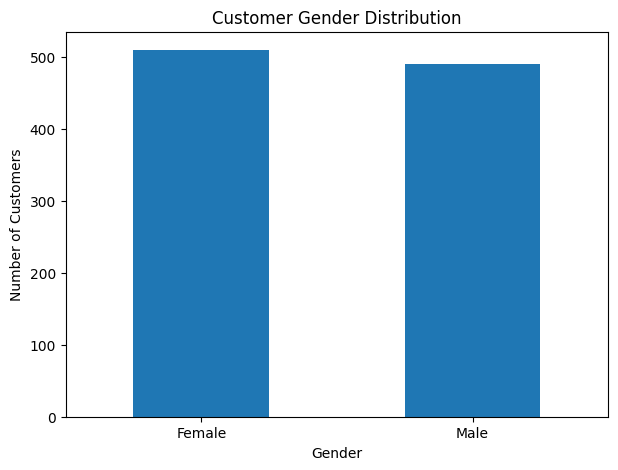

In [22]:
plt.figure(figsize=(7, 5))

gender_count.plot(kind='bar')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### Observation

The customer gender distribution is relatively balanced. Female customers account for 510 records (51%), while male customers account for 490 records (49%). This indicates that the dataset contains a nearly equal representation of both genders.

In [23]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    '0-18',
    '19-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '65+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_group_count = df['Age Group'].value_counts().sort_index()

age_group_count

Age Group
0-18      21
19-25    148
26-35    205
36-45    202
46-55    229
56-65    195
65+        0
Name: count, dtype: int64

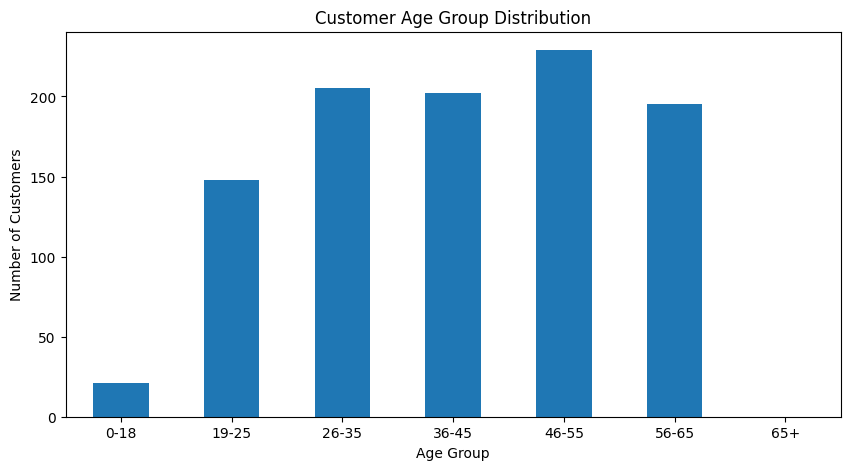

In [24]:
plt.figure(figsize=(10, 5))

age_group_count.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

In [25]:
age_group_count

Age Group
0-18      21
19-25    148
26-35    205
36-45    202
46-55    229
56-65    195
65+        0
Name: count, dtype: int64

In [26]:
age_group_percentage = (age_group_count / len(df) * 100).round(2)

age_group_percentage

Age Group
0-18      2.1
19-25    14.8
26-35    20.5
36-45    20.2
46-55    22.9
56-65    19.5
65+       0.0
Name: count, dtype: float64

### Observation

The 46-55 age group has the highest representation with 229 customers (22.9%). The 26-35 and 36-45 age groups account for 20.5% and 20.2% of customers respectively, while the 56-65 group represents 19.5%. The 0-18 group has only 21 customers (2.1%), and there are no customers in the 65+ age group.

In [27]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

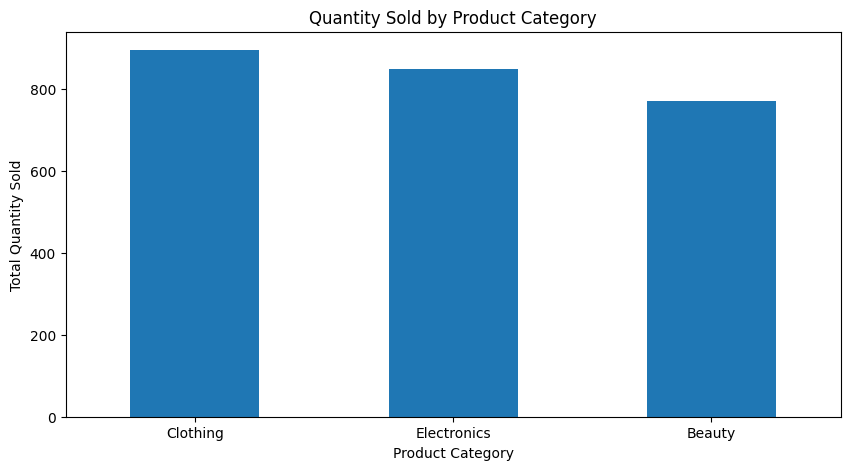

In [28]:
plt.figure(figsize=(10, 5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)

plt.show()

### Observation

Clothing has the highest quantity sold with 894 units, followed by Electronics with 849 units and Beauty with 771 units. This shows that Clothing has the highest sales volume by quantity among the three product categories in the dataset.

In [29]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

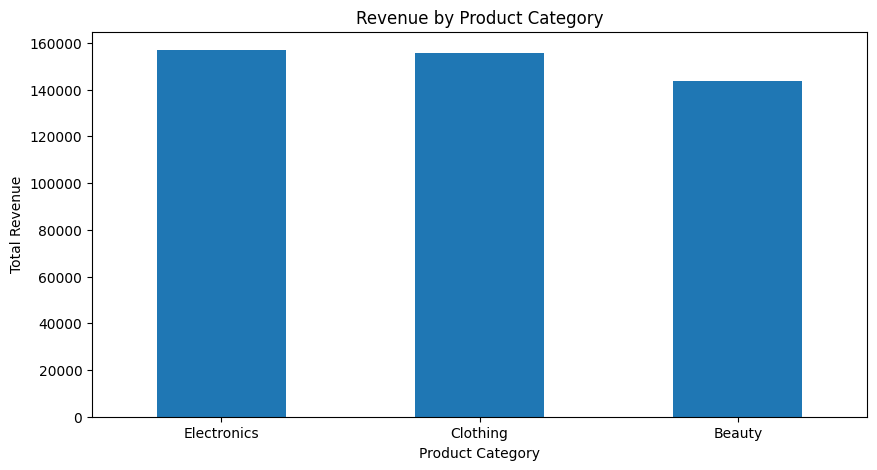

In [30]:
plt.figure(figsize=(10, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

### Observation

Electronics generated the highest revenue with 155,905, followed very closely by Clothing with 155,580. Beauty generated 143,515 in revenue. Although Clothing had the highest quantity sold, Electronics generated slightly higher total revenue, indicating that sales volume and revenue do not always follow the same pattern.

In [31]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


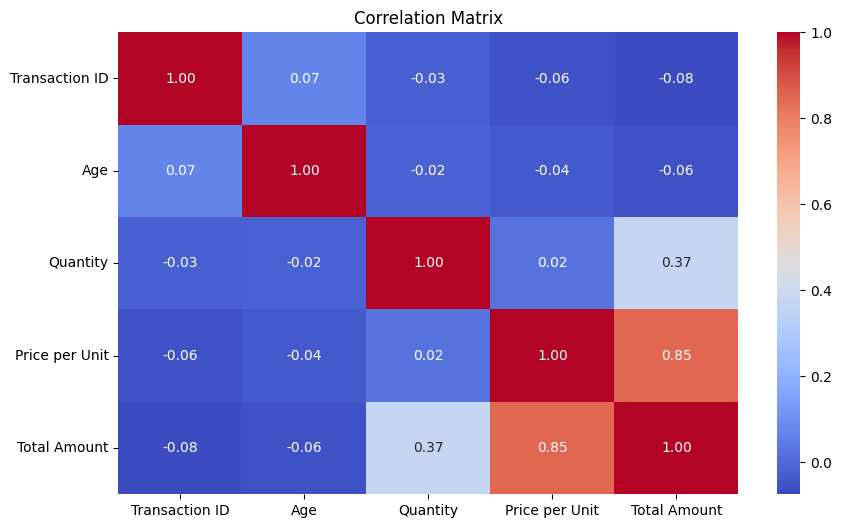

In [32]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

### Observation

The correlation analysis shows a strong positive relationship between Price per Unit and Total Amount, with a correlation coefficient of 0.85. Quantity has a moderate positive relationship with Total Amount at 0.37. Age has a very weak relationship with Total Amount (-0.06), while Quantity and Price per Unit have almost no linear relationship (0.02).

In [33]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

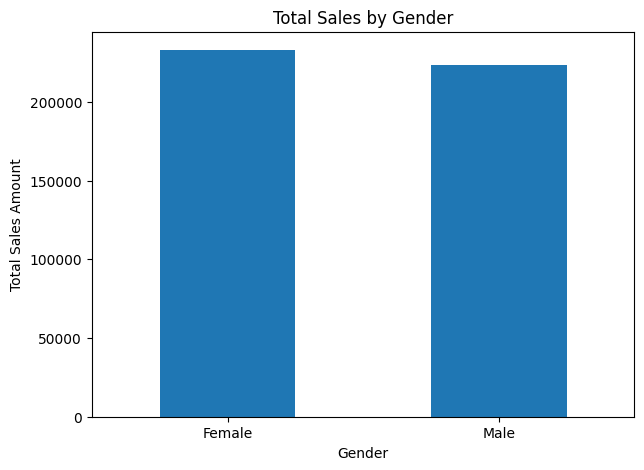

In [35]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=0)

plt.show()

### Observation

Female customers generated a total sales amount of 232,840, while male customers generated 223,160. Although the customer count is nearly balanced between the two groups, female customers generated slightly higher total sales in this dataset.

## Key Insights

1. The dataset contains 1,000 transactions and 9 columns with no missing values or duplicate records.

2. Monthly sales fluctuate throughout the year, with May 2023 recording the highest monthly sales among the complete months.

3. Q4 2023 recorded the highest sales among the complete quarters, with approximately 126K in total sales.

4. The customer gender distribution is almost balanced, with 510 female and 490 male records.

5. The 46-55 age group has the highest representation with 229 customers (22.9%).

6. Clothing has the highest quantity sold with 894 units, while Electronics generated the highest revenue at 155,905.

7. Price per Unit has a strong positive correlation with Total Amount (0.85), while Quantity has a moderate positive correlation with Total Amount (0.37).

8. Female customers generated slightly higher total sales (232,840) than male customers (223,160).

## Business Recommendations

1. **Focus on high-revenue categories:** Electronics generated the highest revenue at 155,905. The business can maintain adequate inventory and use targeted promotions for high-revenue electronics products.

2. **Improve seasonal planning:** Monthly and quarterly sales show noticeable variations. The business can use historical sales patterns to plan inventory and promotional campaigns during stronger sales periods.

3. **Target key customer age groups:** The 46-55 age group is the largest customer segment, representing 22.9% of the records. Marketing campaigns can be designed to better understand and serve this customer segment.

4. **Monitor pricing and product mix:** Price per Unit has a strong positive correlation with Total Amount (0.85). The business can monitor pricing and product mix when planning revenue-growth strategies.

## Conclusion

The exploratory data analysis provided insights into sales trends, customer demographics, product categories, and relationships between numerical variables. The analysis identified monthly and quarterly sales patterns, a balanced gender distribution, the largest customer age group, category-level sales performance, and strong relationships between price per unit and total sales amount. These findings can support data-driven decisions related to inventory planning, customer targeting, pricing, and promotional activities.